<a href="https://colab.research.google.com/github/PutriBalqis134/FYP-HNSCC/blob/main/Multi_omics_DNN_with_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset Input

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import r2_score, mean_squared_error


from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, MultiHeadAttention, LayerNormalization, Dropout, Reshape, Multiply, Input, Lambda, Add
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [ ]:
try:
    sample_info = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/sample_info_updated.csv')

    print("Dataset 'sample_info_updated.csv' loaded successfully.")
    print("\n--- sample_info_updated.csv ---")
    display(sample_info.head())

except FileNotFoundError:
    print("The file 'sample_info_updated.csv' not found. Please ensure the path is correct.")



Dataset 'sample_info_updated.csv' loaded successfully.

--- sample_info_updated.csv ---


,depmapId,cellLineDisplayName
0,ACH-000740,A253
1,ACH-002212,BB30HNC
2,ACH-002213,BB49HNC
3,ACH-000548,BHY
4,ACH-001331,BICR10


### mRNA dataset

In [ ]:
try:
    mRNA_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/mRNAexp_HNSCC_filtered.csv')

    print("Dataset 'mRNAexp_HNSCC_filtered' loaded successfully.")
    print("--- Dataset 1 (mRNAexp_HNSCC_filtered) ---")

except FileNotFoundError:
    print("The file 'mRNAexp_HNSCC_filtered' not found. Please ensure the path is correct.")

mRNA_dataset = mRNA_dataset.set_index("depmapId")
#mRNA_dataset = mRNA_dataset.add_prefix("mRNA_")

display(mRNA_dataset.head())

Dataset 'mRNAexp_HNSCC_filtered' loaded successfully.
--- Dataset 1 (mRNAexp_HNSCC_filtered) ---


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ZNF772 (400720),ZNF257 (113835),PCNX3 (399909),ADAM32 (203102),ACSL5 (51703),LRRC8B (23507),ABCB8 (11194),H3C12 (8356),SND1 (27044),ZNF785 (146540)
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000740,0.070389,0.0,6.782409,1.427606,3.371559,0.014355,1.378512,5.505573,4.245648,3.711495,...,0.042644,0.000000,4.714246,0.344828,0.176323,1.933573,3.645010,0.687061,6.331275,2.946731
ACH-000548,4.694323,0.0,6.706116,1.985500,3.160275,0.400538,4.670161,5.866908,5.122259,3.757023,...,2.304511,0.000000,6.096346,1.063503,3.323370,3.922198,4.621173,0.000000,6.665052,4.429616
ACH-000503,3.094236,0.0,5.843733,1.189034,2.372952,0.150560,1.985500,5.176323,5.262283,3.092546,...,1.495695,1.049631,4.126808,0.432959,0.189034,1.298658,2.961623,0.432959,5.994806,1.937344
ACH-000794,2.625270,0.0,5.509062,1.510962,1.794936,0.238787,3.114367,4.707083,4.924575,2.763412,...,0.250962,0.056584,4.331275,0.263034,2.477677,1.981853,2.646163,0.124328,5.658783,1.959770
ACH-000228,4.120186,0.0,6.420550,2.053111,3.204767,0.594549,3.937344,6.168522,4.856488,3.622930,...,2.173127,0.000000,5.549669,1.220330,3.228049,1.632268,4.841973,0.389567,6.745372,3.111031


In [ ]:
print("mRNA dataset shape: ",mRNA_dataset.shape)
print("Unique cell lines: ", mRNA_dataset.index.nunique())
print("Number of genes: ", len(mRNA_dataset.columns))

mRNA dataset shape:  (87, 16383)
Unique cell lines:  87
Number of genes:  16383


###CNV Dataset

In [ ]:
try:
    cnv_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/CNV_HNSCC_filtered.csv')

    print("Dataset 'CNV_HNSCC_filtered' loaded successfully.")
    print("--- Dataset 2 (CNV_HNSCC_filtered) ---")

except FileNotFoundError:
    print("The file 'CNV_HNSCC_filtered' not found. Please ensure the path is correct.")

cnv_dataset = cnv_dataset.set_index("depmapId")
#cnv_dataset = cnv_dataset.add_prefix("cnv_")

display(cnv_dataset.head())

Dataset 'CNV_HNSCC_filtered' loaded successfully.
--- Dataset 2 (CNV_HNSCC_filtered) ---


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,CASP4 (837),AP2A1 (160),ZNF585A (199704),FUT11 (170384),SMIM10L2B (644596),Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000740,0.728559,0.669183,1.503568,0.781068,0.790443,0.779883,0.758218,1.170253,0.813774,0.783182,...,0.722484,1.126864,1.030269,0.764863,0.904255,0,0,0,0,0
ACH-000548,0.662364,0.621770,1.997582,0.827255,0.842007,0.957908,0.789218,0.835493,1.186515,1.184735,...,1.165758,0.973956,0.922237,1.382828,0.873109,0,0,0,0,0
ACH-000503,0.798144,0.842718,1.347356,0.867580,0.882615,0.983850,0.786156,0.780690,0.998950,0.993453,...,0.784307,1.201555,0.750856,0.796256,0.706318,0,0,0,0,0
ACH-000228,0.521923,0.542177,1.421429,1.063213,1.034554,1.051610,1.034337,1.055296,1.072412,1.098140,...,0.565026,0.958961,0.886782,1.003044,0.842396,0,0,0,0,0
ACH-000771,1.018873,0.951379,1.523361,0.990714,0.984123,0.987912,0.945265,0.998935,0.992171,1.025340,...,0.984264,1.028710,0.971424,0.990663,1.003113,0,0,0,0,0


In [ ]:
print("CNV dataset shape: ",cnv_dataset.shape)
print("Unique cell lines: ", cnv_dataset.index.nunique())
print("Number of genes: ", len(cnv_dataset.columns))

CNV dataset shape:  (62, 16383)
Unique cell lines:  54
Number of genes:  16383


### Mutation dataset

In [ ]:
try:
    mutation_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Mutation_HNSCC_filtered.csv')

    print("Dataset 'Mutation_HNSCC_filtered.csv' loaded successfully.")
    print("--- Dataset 3 (Mutation_HNSCC_filtered.csv) ---")
    display(mutation_dataset.head())

except FileNotFoundError:
    print("The file 'Mutation_HNSCC_filtered.csv' not found. Please ensure the path is correct.")

Dataset 'Mutation_HNSCC_filtered.csv' loaded successfully.
--- Dataset 3 (Mutation_HNSCC_filtered.csv) ---


,Hugo_Symbol,Variant_Classification,Variant_Type,depmapId,Protein_Change,isDeleterious,isTCGAhotspot,TCGAhsCnt,isCOSMIChotspot,COSMIChsCnt,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,depmapId.1
0,AL627309.1,Silent,SNP,ACH-000163,p.V88V,False,False,0,False,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLCN6,Silent,SNP,ACH-000163,p.F337F,False,False,0,False,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KAZN,Missense_Mutation,SNP,ACH-000163,p.S423L,False,False,0,False,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PLEKHM2,Silent,SNP,ACH-000163,p.E107E,False,False,0,False,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HTR6,Silent,SNP,ACH-000163,p.Y208Y,False,False,0,False,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
mutation_dataset["value"] = 1

mutation_matrix = mutation_dataset.pivot_table(
    index="depmapId",
    columns="Hugo_Symbol",
    values="value",
    aggfunc="max"
).fillna(0)

#mutation_matrix = mutation_matrix.add_prefix("MUT_")

In [ ]:
print("original mutation dataset shape: ",mutation_dataset.shape)
print("Unique cell lines: ", mutation_dataset["depmapId"].nunique())
print("Unique mutated genes: ", mutation_dataset["Hugo_Symbol"].nunique())
print("Mutation matrix shape : ", mutation_matrix.shape)

original mutation dataset shape:  (72004, 23)
Unique cell lines:  86
Unique mutated genes:  14169
Mutation matrix shape :  (86, 14169)


### RPPA dataset

In [ ]:
try:
    RPPA_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/RPPA_HNSCC_filtered.csv')

    print("Dataset 'RPPA_HNSCC_filtered.csv' loaded successfully.")
    print("\n--- Dataset 3 (RPPA_HNSCC_filtered.csv) ---")
    display(RPPA_dataset.head())

except FileNotFoundError:
    print("The file 'RPPA_HNSCC_filtered.csv' not found. Please ensure the path is correct.")



Dataset 'RPPA_HNSCC_filtered.csv' loaded successfully.

--- Dataset 3 (RPPA_HNSCC_filtered.csv) ---


,cellLineDisplayName,14-3-3_beta,14-3-3_epsilon_Caution,14-3-3_zeta,4E-BP1,4E-BP1_pS65,4E-BP1_pT37_T46,4E-BP1_pT70,53BP1,A-Raf_pS299_Caution,...,Tuberin_pT1462,VAV1_Caution,VEGFR2,VHL_Caution,XBP1_Caution,XRCC1_Caution,YAP_Caution,YAP_pS127_Caution,YB-1,YB-1_pS102
0,A253,0.130892,-0.000820,0.617585,-0.382009,-0.269067,-0.183803,-0.134472,-0.233986,0.028689,...,0.841031,-0.247704,0.807664,2.584311,0.245446,-0.509366,-0.295740,-0.158626,-0.038519,0.011081
1,BHY,-0.052629,-0.180693,-0.502648,-1.198719,-0.548964,-1.133351,-0.271718,0.175179,0.498291,...,-0.059850,0.559500,1.339209,1.769111,-0.084474,0.199742,-0.030866,-0.018874,0.652908,0.047860
2,BICR16,0.457555,-0.174379,-0.886349,-1.055738,-1.552284,-1.029750,-0.021887,-0.089813,0.327445,...,-0.087861,0.181063,1.211679,4.701157,-0.087078,0.381165,0.064732,-1.130722,0.221681,-0.235150
3,BICR18,0.074944,0.145354,-0.283744,-0.027454,-0.794463,-0.066979,0.081048,-0.328947,0.342150,...,-0.037683,-0.847300,0.439687,1.734026,-0.365264,0.119204,-0.428837,0.678942,-0.439888,0.291701
4,BICR22,0.490437,0.322993,0.169886,-1.235892,-1.577739,-1.140486,-0.063841,-0.336022,1.310299,...,0.037684,-0.144953,0.153362,3.436644,0.228114,-0.090943,0.000000,-0.674989,-0.532208,-0.415448


In [ ]:
#build mapping table to align key ids from all datasets
map_df = sample_info[["depmapId", "cellLineDisplayName"]].drop_duplicates()

rppa_dataset = RPPA_dataset.merge(
    map_df,
    on="cellLineDisplayName",
    how="inner"
)

rppa_dataset = rppa_dataset.set_index("depmapId")
rppa_dataset = rppa_dataset.drop(columns=["cellLineDisplayName"])


In [ ]:
print("original RPPA dataset shape (before id alignment): ",RPPA_dataset.shape)
print("Unique cell lines: ", rppa_dataset.index.nunique())
print("Number of RPPA features: ", rppa_dataset.shape[1])
print("Duplicate cell lines:", rppa_dataset.index.duplicated().sum())

original RPPA dataset shape (before id alignment):  (60, 215)
Unique cell lines:  60
Number of RPPA features:  214
Duplicate cell lines: 0


##Metabolomic Dataset

In [ ]:
try:
    metabolite_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Metabolomic_HNSCC_filtered.csv')

    print("Dataset 'Metabolomic_HNSCC_filtered' loaded successfully.")
    print("--- Dataset 1 (Metabolomic_HNSCC_filtered) ---")

except FileNotFoundError:
    print("The file 'Metabolomic_HNSCC_filtered' not found. Please ensure the path is correct.")

metabolite_dataset = metabolite_dataset.set_index("depmapId")
#mRNA_dataset = mRNA_dataset.add_prefix("mRNA_")

display(metabolite_dataset.head())

Dataset 'Metabolomic_HNSCC_filtered' loaded successfully.
--- Dataset 1 (Metabolomic_HNSCC_filtered) ---


,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,Unnamed: 16374,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000740,6.136619,6.236288,5.695799,6.150986,6.300304,6.510830,5.884781,6.578244,5.819921,6.119440,...,0,0,0,0,0,0,0,0,0,0
ACH-000548,6.296258,5.704879,5.224875,6.056424,5.809342,5.917036,5.724890,5.836584,5.982772,5.885553,...,0,0,0,0,0,0,0,0,0,0
ACH-000503,5.763060,5.834875,5.421896,6.114641,5.692715,5.242634,5.713173,5.713062,5.717858,5.832794,...,0,0,0,0,0,0,0,0,0,0
ACH-000992,5.717874,5.704616,5.505205,5.737122,5.854215,5.235477,5.949481,5.715403,5.619698,5.711744,...,0,0,0,0,0,0,0,0,0,0
ACH-000794,5.982747,5.804074,5.326220,6.356738,5.944529,5.905241,6.047550,5.907058,5.728355,6.024827,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("Metabolomic dataset shape: ",metabolite_dataset.shape)
print("Unique cell lines: ", metabolite_dataset.index.nunique())
print("Number of genes: ", len(metabolite_dataset.columns))

Metabolomic dataset shape:  (71, 16383)
Unique cell lines:  60
Number of genes:  16383


## Drugs IC50 dataset

In [ ]:
try:
    HNSCC_drugs = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/HNSCC_IC50.csv')

    print("Dataset 'HNSCC_IC50.csv' loaded successfully.")
    print("\n--- HNSCC_IC50.csv ---")
    display(HNSCC_drugs.head())

except FileNotFoundError:
    print("The file 'HNSCC_IC50.csv' not found. Please ensure the path is correct.")

Dataset 'HNSCC_IC50.csv' loaded successfully.

--- HNSCC_IC50.csv ---


,Drug Name,Drug ID,cellLineDisplayName,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score
0,Camptothecin,1003,BB30HNC,753531,HNSC,aero_digestive_tract,head_and_neck,-4.016599,0.729320,0.1,0.121919,-0.956747
1,Camptothecin,1003,BB49HNC,753532,HNSC,aero_digestive_tract,head_and_neck,-2.024280,0.867884,0.1,0.109995,0.128007
2,Camptothecin,1003,BHY,753535,HNSC,aero_digestive_tract,head_and_neck,-2.081150,0.872193,0.1,0.068698,0.097043
3,Camptothecin,1003,Ca922,753538,HNSC,aero_digestive_tract,head_and_neck,-3.523805,0.764404,0.1,0.095041,-0.688436
4,Camptothecin,1003,CAL33,753541,HNSC,aero_digestive_tract,head_and_neck,-3.711201,0.746475,0.1,0.094559,-0.790468


In [ ]:
#build mapping table to align key ids from all datasets
map_df = sample_info[["depmapId", "cellLineDisplayName"]].drop_duplicates()

#merge ic50 dataset with with sample info to align depmapId
hnscc_drugs = HNSCC_drugs.merge(
    map_df,
    on="cellLineDisplayName",
    how="inner"
)

hnscc_drugs = hnscc_drugs[["depmapId", "Drug Name", "IC50"]]

print(HNSCC_drugs.shape)
print(hnscc_drugs.shape)
hnscc_drugs.head()

(9408, 12)
(9127, 3)


,depmapId,Drug Name,IC50
0,ACH-002212,Camptothecin,-4.016599
1,ACH-002213,Camptothecin,-2.024280
2,ACH-000548,Camptothecin,-2.081150
3,ACH-002043,Camptothecin,-3.523805
4,ACH-000518,Camptothecin,-3.711201


In [ ]:
#filter drugs with enough data
drug_counts = hnscc_drugs.groupby("Drug Name")["depmapId"].nunique().sort_values(ascending=False)
print(drug_counts.head(20))

valid_drugs = drug_counts[drug_counts > 1].index
ic50_filtered = hnscc_drugs[hnscc_drugs["Drug Name"].isin(valid_drugs)]

Drug Name
Venetoclax      38
VX-11e          38
VE821           38
Ulixertinib     38
Uprosertib      38
AZD5363         38
AZD4547         38
AZ6102          38
AZD3759         38
ABT737          38
AGI-5198        38
AT13148         38
AMG-319         38
Afuresertib     38
Afatinib        38
Alpelisib       38
Alisertib       38
Tamoxifen       38
Taselisib       38
Temozolomide    38
Name: depmapId, dtype: int64


In [ ]:
print("original IC50 dataset shape: ",hnscc_drugs.shape)
print("Unique cell lines: ", hnscc_drugs["depmapId"].nunique())
print("Unique drugs: ", hnscc_drugs["Drug Name"].nunique())

original IC50 dataset shape:  (9127, 3)
Unique cell lines:  38
Unique drugs:  288


#Data Standardization and Normalization


In [ ]:
# index is shared across all datasets
common_ids = (
    mRNA_dataset.index
    .intersection(mutation_matrix.index)
    .intersection(cnv_dataset.index)
    .intersection(rppa_dataset.index)
    .intersection(metabolite_dataset.index)
)

X_mrna = mRNA_dataset.loc[common_ids]
X_mut = mutation_matrix.loc[common_ids]
X_cnv = cnv_dataset.loc[common_ids]
X_rppa = rppa_dataset.loc[common_ids]
X_meta = metabolite_dataset.loc[common_ids]

#X_cnv and X_meta both contains 6 depmapId duplicates, this must be removed
X_cnv = X_cnv.groupby(X_cnv.index).mean()
X_meta = X_meta.groupby(X_meta.index).mean()

print("mRNA :", X_mrna.shape)
print("Mutation :", X_mut.shape)
print("CNV :", X_cnv.shape)
print("RPPA :", X_rppa.shape)
print("Metabolomic :", X_meta.shape)

mRNA : (37, 16383)
Mutation : (37, 14169)
CNV : (37, 16383)
RPPA : (37, 214)
Metabolomic : (37, 16383)


In [ ]:
ic50_filtered = ic50_filtered[ic50_filtered["depmapId"].isin(common_ids)].copy()

print(ic50_filtered.shape)
display(ic50_filtered.head())

(1664, 3)


,depmapId,Drug Name,IC50
2,ACH-000548,Camptothecin,-2.081150
9,ACH-000207,Camptothecin,-2.823572
10,ACH-000846,Camptothecin,-4.026296
15,ACH-000188,Camptothecin,1.148087
16,ACH-000238,Camptothecin,-2.331864


In [ ]:
drug_encoder = LabelEncoder()

ic50_filtered["drug_id"] = drug_encoder.fit_transform(
    ic50_filtered["Drug Name"]
)

num_drugs = len(drug_encoder.classes_)

print("Number of drugs:", num_drugs)

mapping = pd.DataFrame({
    "Drug ID": range(len(drug_encoder.classes_)),
    "Drug Name": drug_encoder.classes_
})

display(mapping)

Number of drugs: 288


,Drug ID,Drug Name
0,0,123138
1,1,123829
2,2,150412
3,3,5-Fluorouracil
4,4,5-azacytidine
...,...,...
283,283,ZM447439
284,284,Zoledronate
285,285,alpha-lipoic acid
286,286,ascorbate (vitamin C)


###Training Dataset

In [ ]:
mrna_lookup = X_mrna.to_dict(orient="index")
mut_lookup = X_mut.to_dict(orient="index")
cnv_lookup = X_cnv.to_dict(orient="index")
rppa_lookup = X_rppa.to_dict(orient="index")
meta_lookup = X_meta.to_dict(orient="index")

mrna_samples = []
mut_samples = []
cnv_samples = []
rppa_samples = []
meta_samples = []
drug_ids = []
targets = []

In [ ]:
for _, row in ic50_filtered.iterrows():

    depmap = row["depmapId"]

    if depmap not in mrna_lookup:
        continue

    mrna_samples.append(
        list(mrna_lookup[depmap].values()))

    mut_samples.append(
        list(mut_lookup[depmap].values()))

    cnv_samples.append(
        list(cnv_lookup[depmap].values()))

    rppa_samples.append(
        list(rppa_lookup[depmap].values()))

    meta_samples.append(
        list(meta_lookup[depmap].values()))

    drug_ids.append(row["drug_id"])

    targets.append(row["IC50"])

In [ ]:
#convert all into numpy array
X_mrna = np.array(mrna_samples)
X_mut = np.array(mut_samples)
X_cnv = np.array(cnv_samples)
X_rppa = np.array(rppa_samples)
X_meta = np.array(meta_samples)
X_drug = np.array(drug_ids)

Y = np.array(targets)

print(X_mrna.shape)
print(X_mut.shape)
print(X_cnv.shape)
print(X_rppa.shape)
print(X_meta.shape)
print(X_drug.shape)
print(Y.shape)

(1664, 16383)
(1664, 14169)
(1664, 16383)
(1664, 214)
(1664, 16383)
(1664,)
(1664,)


#Train-Test Split

In [ ]:
seed = 42

(
    X_mrna_train, X_mrna_test,
    X_mut_train, X_mut_test,
    X_cnv_train, X_cnv_test,
    X_rppa_train, X_rppa_test,
    X_meta_train, X_meta_test,
    X_drug_train, X_drug_test,
    y_train, y_test
) = train_test_split(
    X_mrna, X_mut, X_cnv, X_rppa, X_meta,
    X_drug, Y,
    test_size=0.2,
    random_state=seed
)

print(X_mrna_train.shape)
print(X_mut_train.shape)
print(X_cnv_train.shape)
print(X_rppa_train.shape)
print(X_meta_train.shape)
print(X_drug_train.shape)
print(y_train.shape)

(1331, 16383)
(1331, 14169)
(1331, 16383)
(1331, 214)
(1331, 16383)
(1331,)
(1331,)


In [ ]:
#feature selection : remove low-variance features

mrna_selector = VarianceThreshold(threshold=0.01)
X_mrna_train = mrna_selector.fit_transform(X_mrna_train)
X_mrna_test = mrna_selector.transform(X_mrna_test)
print("mRNA after variance filter:", X_mrna_train.shape)

mut_selector = VarianceThreshold(threshold=0.001)
X_mut_train = mut_selector.fit_transform(X_mut_train)
X_mut_test = mut_selector.transform(X_mut_test)
print("Mutation after variance filter:", X_mut_train.shape)

cnv_selector = VarianceThreshold(threshold=0.01)
X_cnv_train = cnv_selector.fit_transform(X_cnv_train)
X_cnv_test = cnv_selector.transform(X_cnv_test)
print("CNV after variance filter:", X_cnv_train.shape)

rppa_selector = VarianceThreshold(threshold=0.0) #no feature selection needed for RPPA
X_rppa_train = rppa_selector.fit_transform(X_rppa_train)
X_rppa_test = rppa_selector.transform(X_rppa_test)
print("RPPA after variance filter:", X_rppa_train.shape)

meta_selector = VarianceThreshold(threshold=0.01)
X_meta_train = meta_selector.fit_transform(X_meta_train)
X_meta_test = meta_selector.transform(X_meta_test)
print("Metabolomics after variance filter:", X_meta_train.shape)

mRNA after variance filter: (1331, 13642)
Mutation after variance filter: (1331, 2469)
CNV after variance filter: (1331, 13941)
RPPA after variance filter: (1331, 214)
Metabolomics after variance filter: (1331, 214)


In [ ]:
#omics are standardized separately
scaler_mrna = StandardScaler()
X_mrna_train = scaler_mrna.fit_transform(X_mrna_train)
X_mrna_test = scaler_mrna.transform(X_mrna_test)

scaler_mut = StandardScaler()
X_mut_train = scaler_mut.fit_transform(X_mut_train)
X_mut_test = scaler_mut.transform(X_mut_test)

scaler_cnv = StandardScaler()
X_cnv_train = scaler_cnv.fit_transform(X_cnv_train)
X_cnv_test = scaler_cnv.transform(X_cnv_test)

scaler_rppa = StandardScaler()
X_rppa_train = scaler_rppa.fit_transform(X_rppa_train)
X_rppa_test = scaler_rppa.transform(X_rppa_test)

scaler_meta = StandardScaler()
X_meta_train = scaler_meta.fit_transform(X_meta_train)
X_meta_test = scaler_meta.transform(X_meta_test)

# Model Assembly and Compilation
The model is multi-branched

###1st Layer : Omic input branches

In [ ]:
mrna_in = Input(shape=(X_mrna_train.shape[1],), name="mRNA_Input")
mut_in  = Input(shape=(X_mut_train.shape[1],), name="Mutation_Input")
cnv_in  = Input(shape=(X_cnv_train.shape[1],), name="CNV_Input")
rppa_in = Input(shape=(X_rppa_train.shape[1],), name="RPPA_Input")
meta_in = Input(shape=(X_meta_train.shape[1],), name="Metabolite_Input")
drug_in = Input(shape=(1,), name="Drug_Input")

###2nd Layer : Separate Dense branches

In [ ]:
# mRNA branch
mrna_b = Dense(64, activation='relu', kernel_regularizer=l2(0.01), name="mRNA_Dense1")(mrna_in)

mrna_b = Dropout(0.3, name="mRNA_Dropout")(mrna_b)

mrna_b = Dense(32, activation='relu', name="mRNA_Output")(mrna_b)

In [ ]:
# Mutation branch
mut_b = Dense(32, activation='relu', kernel_regularizer=l2(0.0001), name="Mutation_Dense1")(mut_in)

mut_b = Dropout(0.2, name="Mutation_Dropout")(mut_b)

mut_b = Dense(32, activation='relu', name="Mutation_Output")(mut_b)

In [ ]:
# CNV branch
cnv_b = Dense(64, activation='relu', kernel_regularizer=l2(0.01), name="CNV_Dense1")(cnv_in)

cnv_b = Dropout(0.3, name="CNV_Dropout")(cnv_b)

cnv_b = Dense(32, activation='relu', name="CNV_Output")(cnv_b)

In [ ]:
# RPPA branch
rppa_b = Dense(16, activation='relu', kernel_regularizer=l2(0.0005), name="RPPA_Dense1")(rppa_in)

rppa_b = Dropout(0.1, name="RPPA_Dropout")(rppa_b)

rppa_b = Dense(32, activation='relu', name="RPPA_Output")(rppa_b)

In [ ]:
# Metabolite branch
meta_b = Dense(16, activation='relu', kernel_regularizer=l2(0.0005), name="Metabolite_Dense1")(meta_in)

meta_b = Dropout(0.1, name="Metabolite_Dropout")(meta_b)

meta_b = Dense(32, activation='relu', name="Metabolite_Output")(meta_b)

###3rd Layer : Multi-Head Attention Layer

In [ ]:
#stack omic layers
omics = Lambda(lambda x: tf.stack(x, axis=1),name="omics_stack")([
    mrna_b, mut_b, cnv_b, rppa_b, meta_b])

In [ ]:
#attention output
attention, attention_scores = MultiHeadAttention(
    num_heads=4,
    key_dim=8,
    dropout=0.1,
    name="OmicsAttention")(omics,omics, return_attention_scores=True)

#attention normalization
attention = LayerNormalization(
    name="AttentionNorm")(attention + omics)

#attention flatten
attention = Flatten()(attention)

###4th Layer : Concatenation Layer

In [ ]:
#Drug Embedding
drug_emb = Embedding(input_dim=int(X_drug.max()) + 1, output_dim=32, name="Drug_Embedding")(drug_in)
drug_emb = Flatten(name="Drug_Vector")(drug_emb)

In [ ]:
#Concatenate attention layer with drug embedding
merged = Concatenate()([
    attention,
    drug_emb])

###5th & 6th Layer : Dense layers

In [ ]:
x = Dense(64, activation='relu', kernel_regularizer=l2(0.0001))(merged)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.1)(x)

###7th Layer : Output layer

In [ ]:
output = Dense(1, activation='linear')(x)

###Model Compilation

In [ ]:
model = Model(
    inputs=[mrna_in, mut_in, cnv_in, rppa_in, meta_in, drug_in],
    outputs=output
)

model.compile(
    optimizer=Adam(0.0001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mRNA_Input          │ (None, 13642)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mutation_Input      │ (None, 2469)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNV_Input           │ (None, 13941)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RPPA_Input          │ (None, 214)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Metabolite_Input    │ (None, 214)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mRNA_Dense1 (Dense) │ (None, 64)        │    873,152 │ mRNA_Input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mutation_Dense1     │ (None, 32)        │     79,040 │ Mutation_Input[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNV_Dense1 (Dense)  │ (None, 64)        │    892,288 │ CNV_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RPPA_Dense1 (Dense) │ (None, 16)        │      3,440 │ RPPA_Input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Metabolite_Dense1   │ (None, 16)        │      3,440 │ Metabolite_Input… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mRNA_Dropout        │ (None, 64)        │          0 │ mRNA_Dense1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mutation_Dropout    │ (None, 32)        │          0 │ Mutation_Dense1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNV_Dropout         │ (None, 64)        │          0 │ CNV_Dense1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RPPA_Dropout        │ (None, 16)        │          0 │ RPPA_Dense1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Metabolite_Dropout  │ (None, 16)        │          0 │ Metabolite_Dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mRNA_Output (Dense) │ (None, 32)        │      2,080 │ mRNA_Dropout[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mutation_Output     │ (None, 32)        │      1,056 │ Mutation_Dropout… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNV_Output (Dense)  │ (None, 32)        │      2,080 │ CNV_Dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,885,633 (7.19 MB)

 Trainable params: 1,885,633 (7.19 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [ ]:
history = model.fit(
    [ X_mrna_train, X_mut_train, X_cnv_train,
      X_rppa_train, X_meta_train, X_drug_train
    ],
    y_train, validation_data=(
        [ X_mrna_test, X_mut_test, X_cnv_test,
          X_rppa_test, X_meta_test, X_drug_test
        ],
        y_test
    ),
    epochs=100, batch_size=32, verbose=1)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 11.4746 - mae: 2.4429 - val_loss: 9.4846 - val_mae: 1.9091
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.8875 - mae: 2.1150 - val_loss: 8.9542 - val_mae: 1.8228
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.7168 - mae: 2.0629 - val_loss: 8.8506 - val_mae: 1.8192
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.7080 - mae: 2.0640 - val_loss: 8.8935 - val_mae: 1.8399
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.7397 - mae: 2.1053 - val_loss: 8.7332 - val_mae: 1.8241
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.4478 - mae: 2.0508 - val_loss: 8.7616 - val_mae: 1.8273
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.4028 - mae: 2.0178 - val_loss: 8.7144 - val_mae: 1.8506
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 9.2133 - mae: 2.0154 - val_loss: 8.7398 - val_mae: 1.8117
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - 

#Evaluate the Model

In [ ]:
y_pred = model.predict([
    X_mrna_test,
    X_mut_test,
    X_cnv_test,
    X_rppa_test,
    X_meta_test,
    X_drug_test
])

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
MSE: 1.3736517119633453
R2: 0.7920321656011384


In [ ]:
y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)
X_drug_test = np.ravel(X_drug_test)

results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Drug": X_drug_test})

drug_scores = []
for d in np.unique(X_drug_test):

    subset = results_df[results_df["Drug"] == d]
    if len(subset) < 3:
        continue
    r2_d = r2_score(subset["Actual"], subset["Predicted"])
    drug_scores.append((d, r2_d, len(subset)))

drug_scores = pd.DataFrame(drug_scores, columns=["Drug", "R2", "n_samples"])
drug_scores = drug_scores.sort_values("R2", ascending=False)

print("Top 3 Drugs:")
print(drug_scores.head(3))

Top 3 Drugs:
    Drug        R2  n_samples
10   156  0.867562          3
20   205  0.677316          3
18   199  0.590077          3


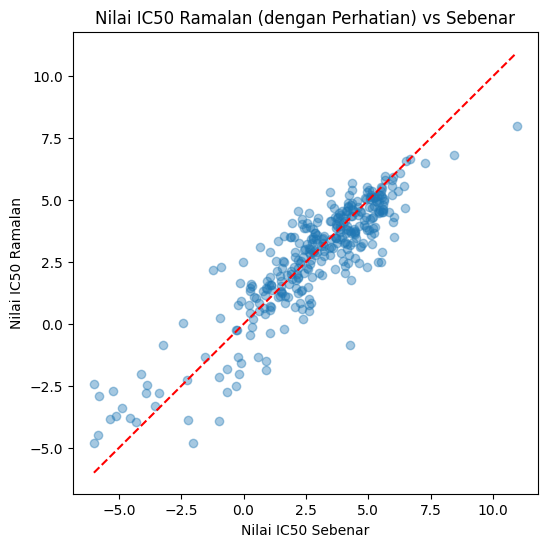

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Nilai IC50 Sebenar")
plt.ylabel("Nilai IC50 Ramalan")
plt.title("Nilai IC50 Ramalan (dengan Perhatian) vs Sebenar")

plt.show()

##Attention weight extraction model

In [ ]:
#model that outputs attention layer only
attention_model = Model(
    inputs=model.inputs,
    outputs=attention_scores)

#attention output for test data
attn_scores = attention_model.predict([
    X_mrna_test, X_mut_test, X_cnv_test,
    X_rppa_test, X_meta_test, X_drug_test
])

print(attn_scores.shape)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(333, 4, 5, 5)


In [ ]:
#convert attention into importance score
mean_scores = attn_scores.mean(axis=(0,1))
importance = mean_scores.mean(axis=0)
importance = mean_scores.mean(axis=0)

omics_names = ["mRNA", "Mutasi", "CNV", "RPPA", "Metabolit"]

df_attn = pd.DataFrame({"Omics": omics_names, "Attention Weight": importance})

print(df_attn)

       Omics  Attention Weight
0       mRNA          0.241152
1     Mutasi          0.128905
2        CNV          0.336074
3       RPPA          0.154923
4  Metabolit          0.138945


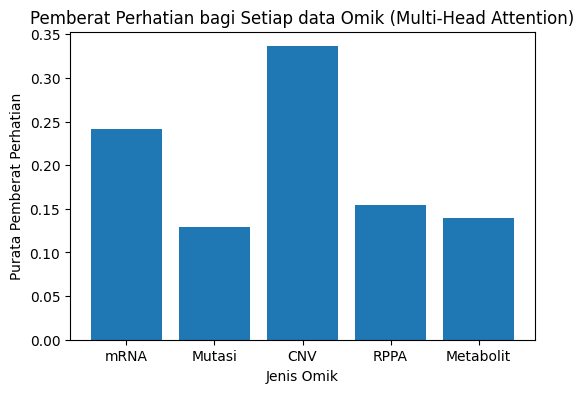

In [ ]:
#Attention weight graph
plt.figure(figsize=(6,4))
plt.bar(df_attn["Omics"], df_attn["Attention Weight"])
plt.title("Pemberat Perhatian bagi Setiap data Omik (Multi-Head Attention)")
plt.ylabel("Purata Pemberat Perhatian")
plt.xlabel("Jenis Omik")
plt.show()

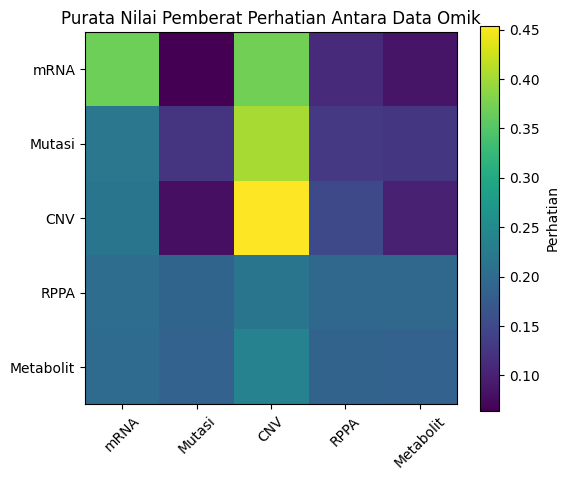

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(mean_scores)

plt.xticks(range(5), omics_names, rotation=45)
plt.yticks(range(5), omics_names)

plt.colorbar(label="Perhatian")
plt.title("Purata Nilai Pemberat Perhatian Antara Data Omik")

plt.show()